#**🏆** Mini Challenge: Data Cleanup - Tweet Dataset (Darija)



📌 Challenge Description:

In this challenge, you will clean a tweet dataset from Hugging Face (`shmuhammad/AfriSenti-twitter-sentiment`), focusing on the Moroccan Darija subset. The goal is to preprocess the text data by removing emojis, usernames, and applying [texte du lien](https://)a custom list of Darija stop words. The cleaned data will then be ready for n-gram analysis.

📊 Dataset Summary:
AfriSenti is the largest sentiment analysis dataset for under-represented African languages, covering 110,000+ annotated tweets in 14 African languages (Amharic, Algerian Arabic, Hausa, Igbo, Kinyarwanda, Moroccan Arabic, Mozambican Portuguese, Nigerian Pidgin, Oromo, Swahili, Tigrinya, Twi, Xitsonga, and Yoruba).

# Part 1: Data Cleaning

In [6]:
#Installing Necessary Packages
#!pip install datasets pandas regex


In [2]:
!pip install -q "datasets<4.0.0" pandas regex


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Douae\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
#Import Necessary Packages
from  datasets  import load_dataset
import pandas as pd
import re

C:\Users\Douae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the Dataset

In [4]:
"""
Load the `shmuhammad/AfriSenti-twitter-sentiment` dataset from the Hugging Face `datasets` library for Moroccan Darija.
"""
darija_dataset = load_dataset("shmuhammad/AfriSenti-twitter-sentiment", "ary", trust_remote_code=True)

In [5]:
""" Identify and select the subset of tweets of the train datasets"""
darija_dataset_df = pd.DataFrame(darija_dataset['train'])


print(darija_dataset_df.shape)
darija_dataset_df.head()

(5583, 2)


,tweet,label
0,hhhhhhhhhhhhhhhhhhhhhh ana ga3ma sma3tt ach ka...,1
1,hhhh hardart jomhorha la fi3lan kadahko lach m...,1
2,: أتفهم العثماني وأتفهم الجدل الشعبي. الحل: حا...,1
3,كان افظل حاكم عربي',0
4,ماريانو راخوي : خاص المغرب واسبانيا يشرحو للرأ...,1


## Remove Emojis From Tweets

In [6]:


def remove_emojis(tweet):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"   # emoticons
        "\U0001F300-\U0001F5FF"   # symbols & pictographs
        "\U0001F680-\U0001F6FF"   # transport & map
        "\U0001F1E0-\U0001F1FF"   # flags (iOS)
        "\U0001F923"              
        "\U0001F97A"              
        "\U0001F914"              
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', tweet)

darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_emojis)
darija_dataset_df.head()

,tweet,label
0,hhhhhhhhhhhhhhhhhhhhhh ana ga3ma sma3tt ach ka...,1
1,hhhh hardart jomhorha la fi3lan kadahko lach m...,1
2,: أتفهم العثماني وأتفهم الجدل الشعبي. الحل: حا...,1
3,كان افظل حاكم عربي',0
4,ماريانو راخوي : خاص المغرب واسبانيا يشرحو للرأ...,1


You can use this ressource emojis unicode: https://apps.timwhitlock.info/emoji/tables/unicode

In [7]:
# remove the emojis from the dataset
darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_emojis)

In [8]:
darija_dataset_df.head()

,tweet,label
0,hhhhhhhhhhhhhhhhhhhhhh ana ga3ma sma3tt ach ka...,1
1,hhhh hardart jomhorha la fi3lan kadahko lach m...,1
2,: أتفهم العثماني وأتفهم الجدل الشعبي. الحل: حا...,1
3,كان افظل حاكم عربي',0
4,ماريانو راخوي : خاص المغرب واسبانيا يشرحو للرأ...,1


## Remove user name from tweets

In [9]:

def remove_user(tweet):
    return re.sub(r"@[A-Za-z0-9_]+", ' ', tweet)

darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_user)
darija_dataset_df.sample(5)

,tweet,label
2675,أين هي الكرامة حتى تكون مبعثرة .يمكن القول بال...,2
4149,tkhalt lik mea rask fach katkun kathwi,1
5506,والأحرار من أبناء المغرب الحبيب كلهم معى الإصل...,0
2506,هههه البام ههه لا لا اخي الكريم قول نفقص الشعب...,2
962,لتطوير الاستثمارات والمبادلات بين المغرب و الج...,1


In [10]:
#remove the user names from the dataset
darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_user)


In [11]:
darija_dataset_df.sample(10)
darija_dataset_df.info

<bound method DataFrame.info of                                                   tweet  label
0     hhhhhhhhhhhhhhhhhhhhhh ana ga3ma sma3tt ach ka...      1
1     hhhh hardart jomhorha la fi3lan kadahko lach m...      1
2     : أتفهم العثماني وأتفهم الجدل الشعبي. الحل: حا...      1
3                                   كان افظل حاكم عربي'      0
4     ماريانو راخوي : خاص المغرب واسبانيا يشرحو للرأ...      1
...                                                 ...    ...
5578            wah akhouya titiz o dikchi 3la 9ad lhal      1
5579  soukaina dik nhar drt follow haydato o 9lt f k...      1
5580                kiban liya stormy kid7ak mn hna ana      1
5581            woww ghadi tefra7 bzzf thank uu aaliaaa      0
5582  الواقع وهوأن هؤلاء دخلوا مستنقعا لن يخرجوا منه...      2

[5583 rows x 2 columns]>

## Remove latin letter

In [12]:
def remove_latin(tweet):
    latin_re =  "[A-Za-z]+"
    return re.sub(latin_re, ' ', tweet)


In [13]:
#remove latin words
darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_latin)

## Removing Dublicate Rows

In [14]:
darija_dataset_df.drop_duplicates(inplace = True)
darija_dataset_df

,tweet,label
0,3 3 9 3,1
1,3 3 3,1
2,: أتفهم العثماني وأتفهم الجدل الشعبي. الحل: حا...,1
3,كان افظل حاكم عربي',0
4,ماريانو راخوي : خاص المغرب واسبانيا يشرحو للرأ...,1
...,...,...
5578,3 9,1
5579,9,1
5580,7,1
5581,7,0


## Remove Punctuation

In [15]:
import re
def remove_ponct(tweet):
    ponct_re =  "[^\w\s]+"
    return re.sub(ponct_re, ' ', tweet)



<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Douae\AppData\Local\Temp\ipykernel_35024\779095067.py:3: SyntaxWarning: invalid escape sequence '\w'
  ponct_re =  "[^\w\s]+"


In [16]:
#remove ponctuation
darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_ponct)

## Tokenization

In [17]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
def Tokenize(tweet):
    return word_tokenize(tweet)

darija_dataset_df["tweet_token"] = darija_dataset_df['tweet'].apply(Tokenize)
darija_dataset_df.head()



[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Douae\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,tweet,label,tweet_token
0,3 3 9 3,1,"[3, 3, 9, 3]"
1,3 3 3,1,"[3, 3, 3]"
2,أتفهم العثماني وأتفهم الجدل الشعبي الحل حا...,1,"[أتفهم, العثماني, وأتفهم, الجدل, الشعبي, الحل,..."
3,كان افظل حاكم عربي,0,"[كان, افظل, حاكم, عربي]"
4,ماريانو راخوي خاص المغرب واسبانيا يشرحو للرأ...,1,"[ماريانو, راخوي, خاص, المغرب, واسبانيا, يشرحو,..."


## Remove Stops Words


In [21]:
#Import darija stopwords dataset
# the darija stop words will be found here https://github.com/zerouani/darija-stop-words/blob/main/stopwords.txt, change the extension and the head name
darija_stop_words_df = pd.read_csv(
    "./darija_stop_words.csv",
    header=None,       
    names=['word']     
)

darija_stop_words = darija_stop_words_df['word'].tolist()

print(f"Total stop words loaded: {len(darija_stop_words)}")
print(darija_stop_words[:10])

Total stop words loaded: 714
['ـ', '،', '.', 'أب', 'أبريل', 'أربعاء', 'أكتوبر', 'أم', 'أنا', 'أنت']


In [26]:
# Build ONCE outside
darija_stop_set = {word.strip() for word in darija_stop_words}

def remove_stop(tokens):
    return [token.strip() for token in tokens if token.strip() not in darija_stop_set]

In [32]:
def remove_stop(tokens, stop_lst):
    stop_set = {w.strip() for w in stop_lst}
    return [t.strip() for t in tokens if t.strip() not in stop_set]

In [33]:
all_token = [token for list_token in darija_dataset_df['tweet_token'] for token in list_token]

# Part 2: N-Grams Analysis

In [34]:
#Install Necessary Librairies
!pip install nltk pandas matplotlib seaborn wordcloud networkx arabic-reshaper python-bidi

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 12.5 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   ---------- ----------------------------- 1/4 [networkx]
   --------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Douae\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Unigrams

In [35]:
from collections import Counter
unigram_counts = Counter(all_token)

print(f"Unique unigrams: {len(unigram_counts)}")
unigram_counts.most_common(10)

Unique unigrams: 16566


[('3', 2657),
 ('9', 1164),
 ('7', 795),
 ('على', 594),
 ('الله', 511),
 ('المغرب', 199),
 ('يا', 177),
 ('ديال', 174),
 ('2', 173),
 ('بنكيران', 155)]

## Barplot of Unigrams

In [40]:
#Import Necessary Packages
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

C:\Users\Douae\AppData\Local\Temp\ipykernel_35024\4289676295.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=bidi_words, palette="viridis")
C:\Users\Douae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


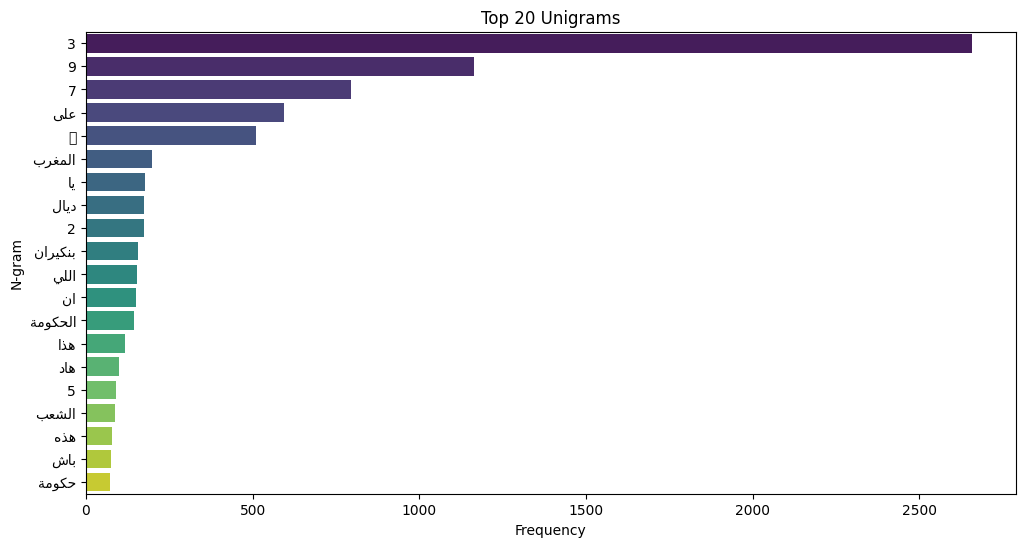

In [42]:
def plot_top_n_grams(ngram_counts, n, title):
    top_n = ngram_counts.most_common(n)
    words, counts = zip(*top_n)
    plt.figure(figsize=(12, 6))
    reshaped_words = [arabic_reshaper.reshape(word) for word in words]
    bidi_words = [get_display(word) for word in reshaped_words]
    sns.barplot(x=list(counts), y=bidi_words, palette="viridis")
    plt.title(f"Top {n} {title}")
    plt.xlabel("Frequency")
    plt.ylabel("N-gram")
    plt.show()

plot_top_n_grams(unigram_counts, 20, "Unigrams")


## WordCloud

In [ ]:

# Download the Arabic font if not already present
import os
import urllib.request

font_path = 'NotoNaskhArabic-VariableFont_wght.ttf'

if not os.path.exists(font_path):
    print("Downloading Noto Naskh Arabic font...")
    url = "https://github.com/notofonts/arabic/raw/main/fonts/NotoNaskhArabic-VariableFont_wght.ttf"
    try:
        urllib.request.urlretrieve(url, font_path)
        print(f"Font downloaded successfully to {font_path}")
    except Exception as e:
        print(f"Error downloading font: {e}")
        print("Please download manually from: https://arbfonts.com/noto-naskh-arabic-regular-font-download.html")
else:
    print(f"Font file {font_path} already exists")


In [43]:
#Import Necessary Librairies
import matplotlib.pyplot as plt
from wordcloud import WordCloud

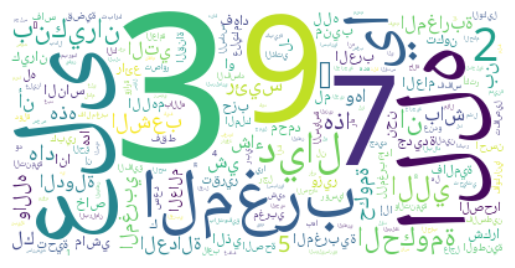

In [50]:
# download the ttf file from this website: https://arbfonts.com/noto-naskh-arabic-regular-font-download.html


cloud_ar = WordCloud(
    font_path='NotoNaskhArabic-VariableFont_wght.ttf',
    background_color="white"
).generate_from_frequencies(unigram_counts)

plt.imshow(cloud_ar, interpolation='bilinear')
plt.axis('off')

plt.savefig("ary.png", bbox_inches='tight')
plt.show()

In [51]:
# Add this to your cleaning pipeline
def remove_numbers(tweet):
    return re.sub(r'\d+', ' ', tweet)

darija_dataset_df['tweet'] = darija_dataset_df['tweet'].apply(remove_numbers)

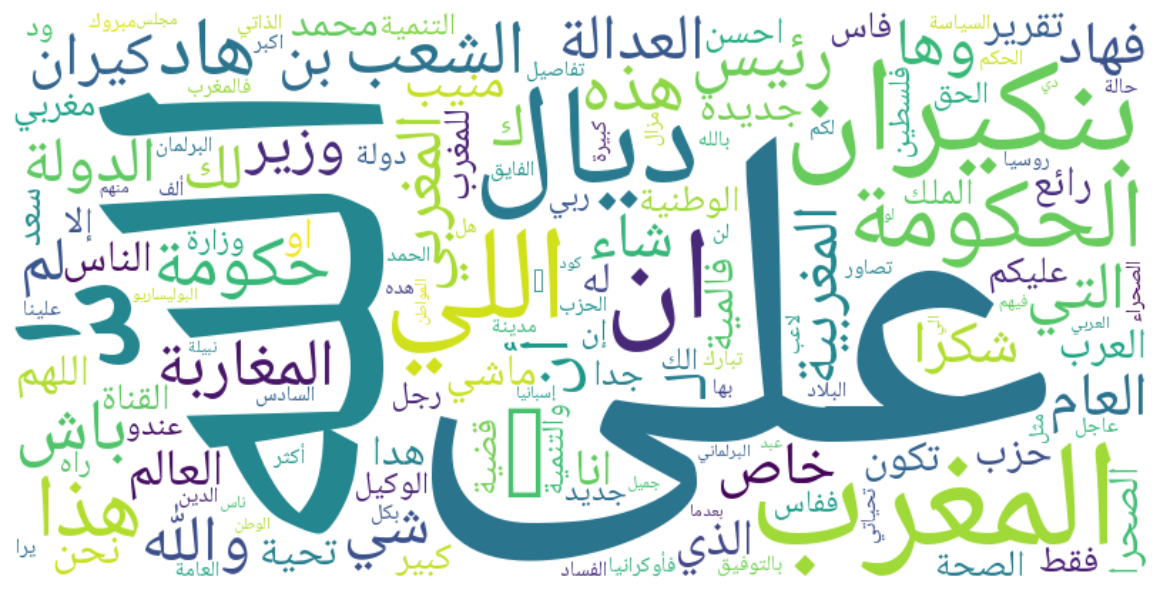

In [57]:
import arabic_reshaper
from bidi.algorithm import get_display
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Reshape Arabic text for correct display
reshaped_counts = {
    get_display(arabic_reshaper.reshape(word)): count
    for word, count in unigram_counts.items()
    if word.strip() and not word.isdigit()   # skip empty & numbers
}

cloud_ar = WordCloud(
    font_path='NotoNaskhArabic-VariableFont_wght.ttf',
    background_color="white",
    width=800,
    height=400,
    max_words=150
).generate_from_frequencies(reshaped_counts)

plt.figure(figsize=(12, 6))
plt.imshow(cloud_ar, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.savefig("ary.png", dpi=150, bbox_inches='tight')
plt.show()

In [58]:
all_token = [
    token
    for token_list in darija_dataset_df['tweet_token']
    for token in token_list
    if token.strip() and not token.isdigit()
]
print(f"Total tokens after removing numbers: {len(all_token)}")

Total tokens after removing numbers: 36712


In [59]:
unigram_counts = Counter(all_token)
print(f"Unique unigrams: {len(unigram_counts)}")
unigram_counts.most_common(10)

Unique unigrams: 16398


[('على', 594),
 ('الله', 511),
 ('المغرب', 199),
 ('يا', 177),
 ('ديال', 174),
 ('بنكيران', 155),
 ('اللي', 153),
 ('ان', 151),
 ('الحكومة', 145),
 ('هذا', 116)]

C:\Users\Douae\AppData\Local\Temp\ipykernel_35024\259642688.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=bidi_words, palette="viridis")
C:\Users\Douae\AppData\Local\Temp\ipykernel_35024\259642688.py:20: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Douae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


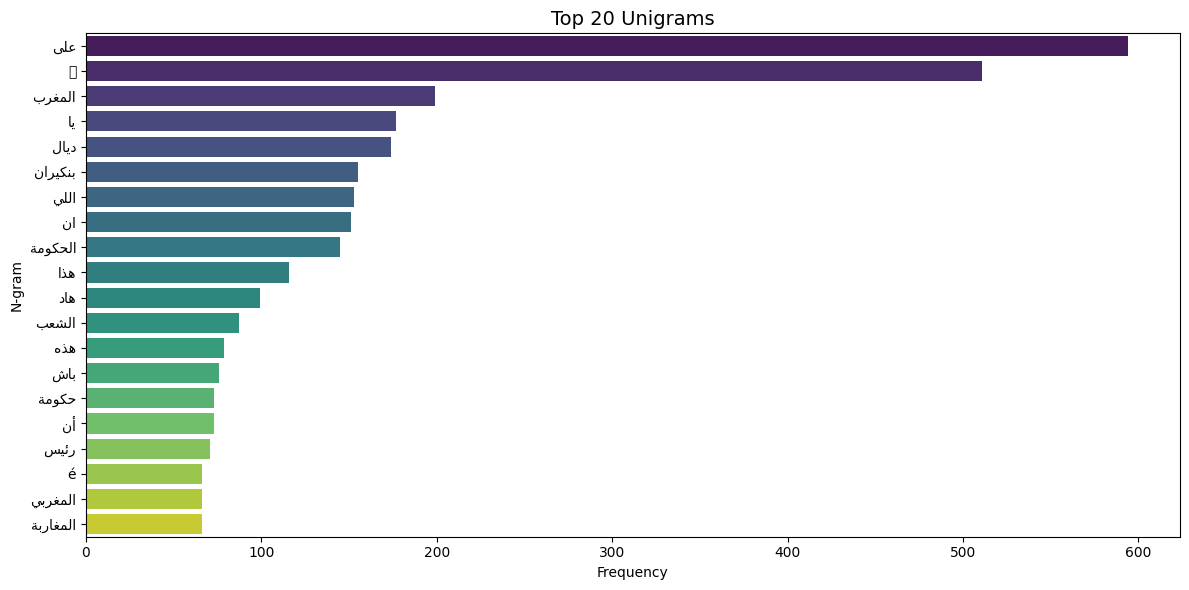

In [60]:
plot_top_n_grams(unigram_counts, 20, "Unigrams")